## Abstract (Before looking at the Coursework)
In this coursework, I will be tacking Q1 titled “Controlling the Spread of Epidemics”. Please note the following… I have conducted my entire report here in this piece of documentation and have matched each numbered section (e.g. 3.4) to the corresponding part of the Jupyter notebook (where applicable). Bear in mind this report was explored into a pdf from ‘Notion’. Also, I have included all of the graphical outputs of from the notebook within this report for a clearer comparison and discussion of the results. Bear in mind the Jupyter notebook contains additional comments, links, and resources, such as documentation used to support and reference the code, along with brief explanations of how certain parts of the implementation work.


## Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

## 1. Standard SIR model


In [4]:
# Parameters used for SIR model
N = 1000
I0 = 1
R0 = 0
S0 = N - I0 - R0

beta = 0.2
gamma = 0.1

y0 = np.array([S0, I0, R0], dtype=float)

tmax = 160

## 2. Defining the SIR system

SIR model used here follows the 

In [10]:
# Differential equations
def der(X, t, N, beta, gamma):
    S, I, R = X
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

## 3. Part 1: Comparing Euler Method with odeint

### 3.1 Reference solution using `odeint`

From my own understanding, the odient function is used to solve systems of ordinary differential equations numerically and is commonly utilised in scientific computing for accurate approximations ([Solve Differential Equations with ODEINT Function of SciPy module in Python - GeeksforGeeks](https://www.geeksforgeeks.org/python/solve-differential-equations-with-odeint-function-of-scipy-module-in-python/)).

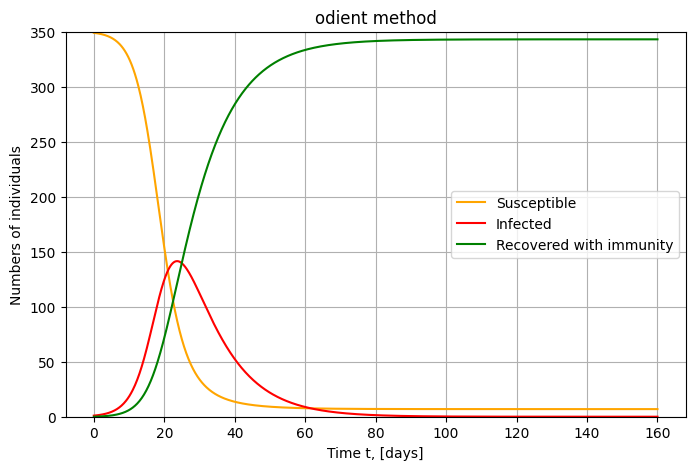

In [34]:
# Adapted from Euler's Method template in Lab M2 notes (in Appendix): https://moodle.ecs.soton.ac.uk/pluginfile.php/78177/mod_page/intro/aice_LabTwo%20%281%29.pdf 

# Time grid (in days)
Nt = 1000
t = np.linspace(0, tmax, Nt + 1)

X0 = [S0, I0, R0] # Initial conditions vector

# Integrating the SIR equations over the time grid
res = odeint(der, X0, t, args=(N, beta, gamma))
S, I, R = res.T

# Plotting the data
plt.figure(figsize=(8, 5))
plt.plot(t, S, color="orange", label="Susceptible")
plt.plot(t, I, 'r', label="Infected")
plt.plot(t, R, 'g', label="Recovered with immunity")
plt.xlabel("Time t, [days]")
plt.ylabel("Numbers of individuals")
plt.title("odient method")
plt.ylim([0, N])
plt.grid(True)
plt.legend()
plt.show()

### 3.2 Euler's method

In [16]:
# Euler method - taken inspiration from https://lemesurierb.people.charleston.edu/numerical-methods-and-analysis-python/main/ODE-IVP-1-Euler-python.html.
# and also from https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/chapter22.03-The-Euler-Method.html
def Euler(func, X0, t):
    # Find step size from time grid
    h = t[1] - t[0]
    Nt = len(t)

    # Set up array for S, I and R values
    X = np.zeros((Nt, 3))
    X[0] = X0

    # Move through each time step
    for n in range(1, Nt):
        # Get derivative from previous position
        dX = func(X[n-1], t[n-1])

        # If Euler starts producing nan/inf values,
        # stop the sim here
        if not np.all(np.isfinite(dX)):
            X[n:] = np.nan
            break

        # Euler update
        X_next = X[n-1] + h * dX

        # Added this as a debugging/cut-off check
        # to be used for larger step sizes where Euler would became unstable
        if not np.all(np.isfinite(X_next)) or np.max(np.abs(X_next)) > 1e6:
            X[n:] = np.nan
            break

        X[n] = X_next

    return X

### Investigating the effect of time resolution on Euler accuracy

In [23]:
# Wrapper so Euler can use der with fixed model parameters
def der_euler(X, t):
    return np.array(der(X, t, N, beta, gamma), dtype=float) # return as numpy array for matplotlib


# Interpolate odeint solution -> onto Euler time grid
def interp_ref(t_new, t_ref, y_ref):
    return np.interp(t_new, t_ref, y_ref)


# Error analysis
dt_values = np.linspace(0.1, 10.0, 30)  # Different step sizes from 0.1 - 10 days

peak_errors = []
avg_errors = []

for dt in dt_values:
    # Build time grid for this choice of step size
    Nt = int(tmax / dt)
    t = np.linspace(0, tmax, Nt + 1)

    # Solving using Euler's method
    Xe = Euler(der_euler, y0, t)
    I_euler = Xe[:, 1]

    # If euler becomes unstable (>=9 days time step),
    # skip this run and store nan instead
    if not np.all(np.isfinite(I_euler)):
        peak_errors.append(np.nan)
        avg_errors.append(np.nan)
        continue

    I_true = interp_ref(t, t_ref, I_ref)  # Interpolation...
    error = np.abs(I_euler - I_true)  # Calculating abs error between Euler and odeint

    # Storing max and mean error for this step size
    peak_errors.append(np.max(error))
    avg_errors.append(np.mean(error))

# Converting lists -> np.arrays...
peak_errors = np.array(peak_errors)
avg_errors = np.array(avg_errors)

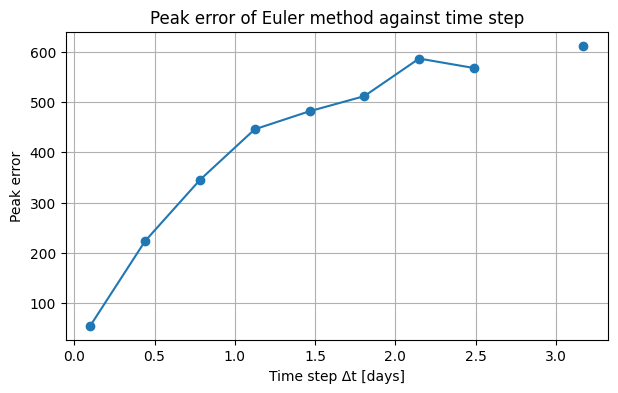

In [24]:
# Graph showing the peak error of Euler's method against time step (Δt)

plt.figure(figsize=(7, 4))
plt.plot(dt_values, peak_errors, "o-") # markers in matplotlib: https://www.w3schools.com/python/matplotlib_markers.asp
plt.grid(True)
plt.xlabel("Time step Δt [days]")
plt.ylabel("Peak error")
plt.title("Peak error of Euler method against time step")
plt.show()

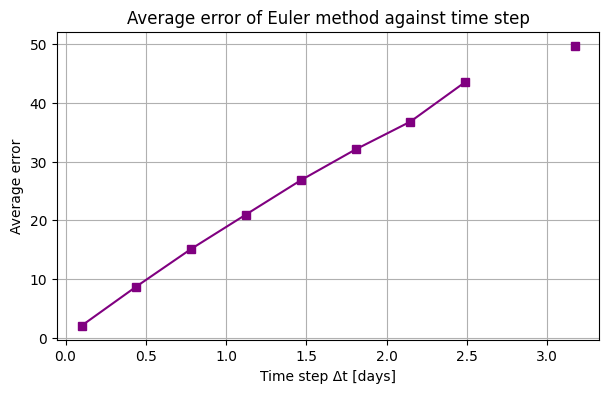

In [25]:
# Graph showing the average error of Euler's method against time step (Δt)

plt.figure(figsize=(7, 4))
plt.plot(dt_values, avg_errors, "s-", color="purple")
plt.grid(True)
plt.xlabel("Time step Δt [days]")
plt.ylabel("Average error")
plt.title("Average error of Euler method against time step")
plt.show()

## 4. Part 2 — Adding control to the infection rate

### 4.1 Modified Model

More controlled version of the SIR model where beta is no longer constant and no changes with the infection level

In [27]:
def sir_controlled_rhs(y, t, gamma, N, eta):
    S, I, R, beta_t = y
    dSdt = -beta_t * S * I / N
    dIdt = beta_t * S * I / N - gamma * I
    dRdt = gamma * I
    dbetadt = -eta * I * beta_t * (1 - beta_t)
    return [dSdt, dIdt, dRdt, dbetadt]

beta0 = 0.2 # Initial value of beta
y0_controlled = np.array([S0, I0, R0, beta0], dtype=float) # New state vector now including beta as well

t_control = np.linspace(0, tmax, 2000) # Smooth plotting


### 4.2 Results

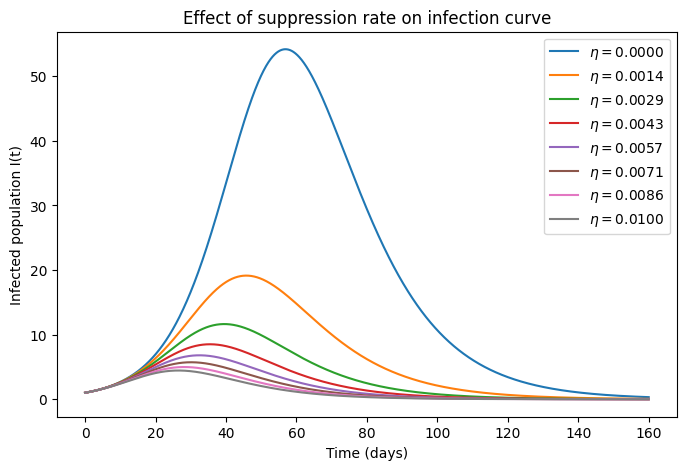

In [28]:
eta_values = np.linspace(0.0, 0.01, 8) # Different eta values for testing
peak_infections = []

plt.figure(figsize=(8, 5))
for eta in eta_values:
    # Solving extended SIR system for this eta
    Yc = odeint(sir_controlled_rhs, y0_controlled, t_control, args=(gamma, N, eta))
    S_c, I_c, R_c, beta_c = Yc.T

    peak_infections.append(I_c.max()) # Recording highest value reached by I(t)
    plt.plot(t_control, I_c, label=fr"$\eta={eta:.4f}$") # Plotting infected curve for comparison

plt.xlabel("Time (days)")
plt.ylabel("Infected population I(t)")
plt.title("Effect of suppression rate on infection curve")
plt.legend()
plt.show()

peak_infections = np.array(peak_infections) # Converting to array for plotting


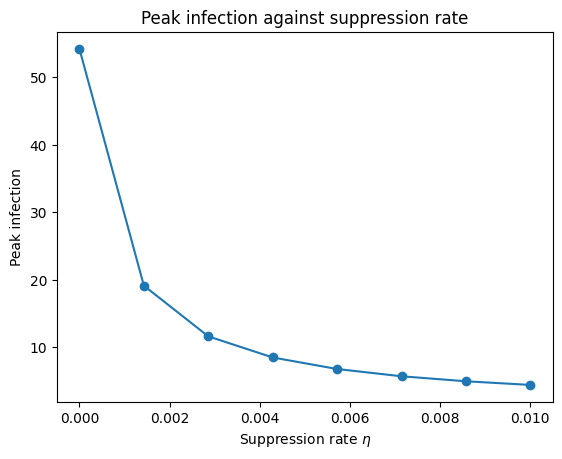

In [29]:
# Graph showing peak infection plotted against the suppression parameter η 
plt.plot(eta_values, peak_infections, "o-")
plt.xlabel(r"Suppression rate $\eta$")
plt.ylabel("Peak infection")
plt.title("Peak infection against suppression rate")
plt.show()

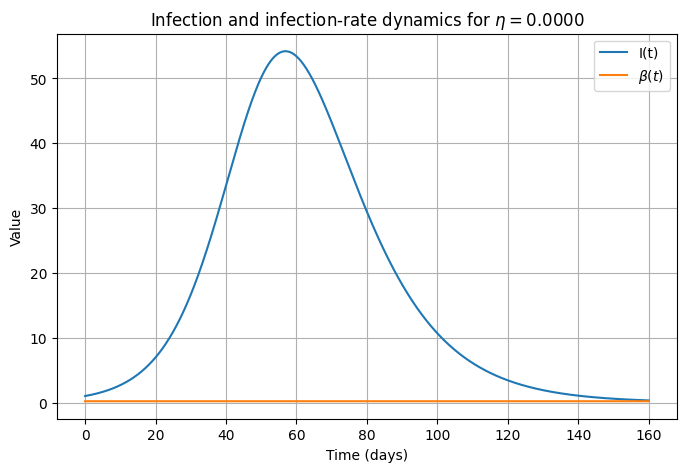

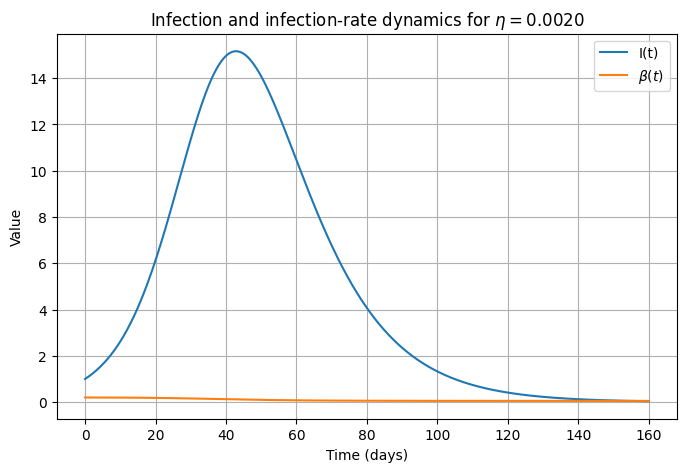

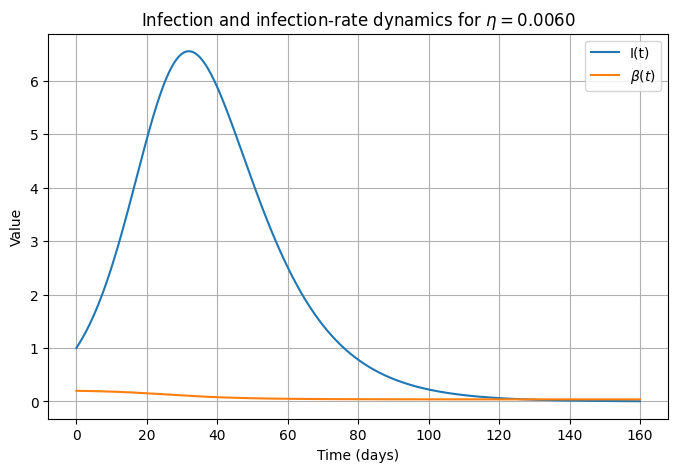

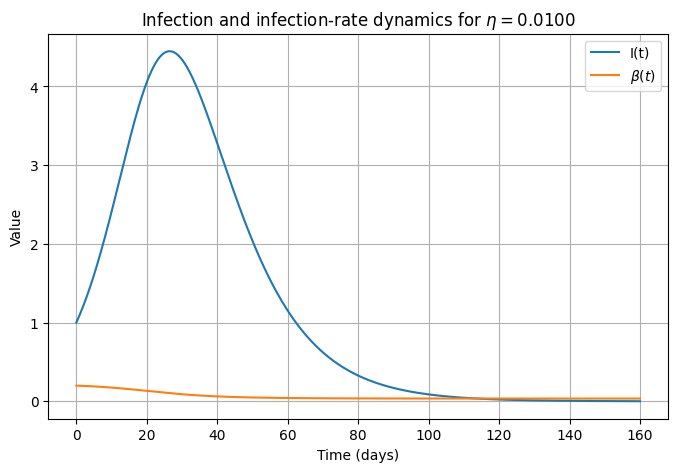

In [30]:
# NOT MENTIONED IN THE REPORT: 
#   Optional extra plot to show how beta changes (used for debugging)

etas_to_show = [0.0, 0.002, 0.006, 0.01]

for eta in etas_to_show:
    # Solving controlled SIR system again
    # for a few selected controllled eta values
    Yc = odeint(sir_controlled_rhs, y0_controlled, t_control, args=(gamma, N, eta))
    S_c, I_c, R_c, beta_c = Yc.T

    plt.figure(figsize=(8, 5))

    # Plotting infected population and beta together
    # this is so that it is easier to see how they change with each other
    plt.plot(t_control, I_c, label="I(t)")
    plt.plot(t_control, beta_c, label=r"$\beta(t)$")
    plt.xlabel("Time (days)")
    plt.ylabel("Value")
    plt.title(fr"Infection and infection-rate dynamics for $\eta={eta:.4f}$")
    plt.legend()
    plt.grid(True)
    plt.show()

## 5. Extension: Runge–Kutta Method (RK4)

In [31]:
# Sources for inspiration/reference:
    # https://www.geeksforgeeks.org/dsa/runge-kutta-4th-order-method-solve-differential-equation/
    # https://jonshiach.github.io/ODEs-book/_pages/B_Python_code.html

# Runge-Kutta 4th order method
def RK4(func, X0, t):
    # Step size from time grid
    h = t[1] - t[0]
    Nt = len(t)

    # Placeholder being used to store solutions for S, I, R
    X = np.zeros((Nt, 3))
    X[0] = X0

    # Applying RK4 step through the whole time grid
    for n in range(1, Nt):
        # Four slope estimates
        k1 = func(X[n-1], t[n-1])
        k2 = func(X[n-1] + 0.5 * h * k1, t[n-1] + 0.5 * h)
        k3 = func(X[n-1] + 0.5 * h * k2, t[n-1] + 0.5 * h)
        k4 = func(X[n-1] + h * k3, t[n-1] + h)

        X[n] = X[n-1] + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4) # RK4 update formula

    return X


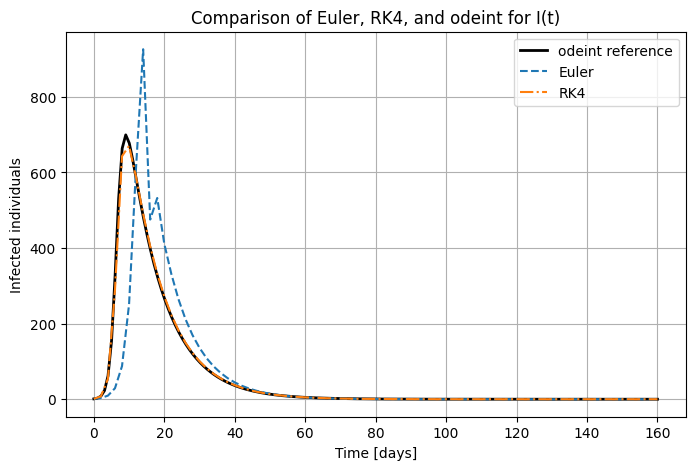

In [37]:
# Reference solution
t_ref = np.linspace(0, tmax, Nt) # Nt from 2nd code block
sol_ref = odeint(der, y0, t_ref, args=(N, beta, gamma)) 

# S_ref and R_ref not used for the graph -> using only infected curve

# S_ref = sol_ref[:, 0]
I_ref = sol_ref[:, 1] 
# R_ref = sol_ref[:, 2]

# Choose one time step for comparison
dt_compare = 2.0
Nt_compare = int(tmax / dt_compare)
t_compare = np.linspace(0, tmax, Nt_compare + 1)

# Computing Euler and RK4 solutions
Xe = Euler(der_euler, y0, t_compare)
Xrk = RK4(der_euler, y0, t_compare)

I_euler = Xe[:, 1]
I_rk4 = Xrk[:, 1]
I_true = np.interp(t_compare, t_ref, I_ref)

# Plotting the comparison...
plt.figure(figsize=(8, 5))
plt.plot(t_ref, I_ref, color="black", linewidth=2, label="odeint reference")
plt.plot(t_compare, I_euler, "--", label="Euler")
plt.plot(t_compare, I_rk4, "-.", label="RK4")
plt.grid(True)
plt.xlabel("Time [days]")
plt.ylabel("Infected individuals")
plt.title("Comparison of Euler, RK4, and odeint for I(t)")
plt.legend()
plt.show()